<a href="https://colab.research.google.com/github/medha327/my_project1/blob/master/crack_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project : CNN-Based Steel Surface Crack Detection**

In this project, we are building a Convolutional Neural Network (CNN) to automatically detect surface cracks in steel plates. This type of system is used in industries like Tata Steel to improve quality inspection, reduce manufacturing defects and support predictive maintenance.

We use the NEU Surface Defect Dataset, which contains high-resolution grayscale images of different types of defects such as cracks, scratches, patches, inclusion, pitted surface and rolled-in scale. For our task, we convert the dataset into two categories:

Crack (defective steel surface)

No-crack (normal steel surface)

Install Dependencies

In [ ]:
!pip install tensorflow matplotlib scikit-learn

Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import os


Upload & Extract NEU Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile

for fn in uploaded.keys():
    zip_path = fn

extract_path = "/content/NEU_EXTRACTED"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)


Saving NEU-DET.zip to NEU-DET (2).zip
Extracted to: /content/NEU_EXTRACTED


Create Crack vs Non-Crack Dataset Automatically

In [ ]:
import shutil

base_dir = "/content/NEU_BINARY"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")

for p in [train_dir, val_dir]:
    os.makedirs(os.path.join(p, "crack"), exist_ok=True)
    os.makedirs(os.path.join(p, "no_crack"), exist_ok=True)

import glob
all_images = glob.glob(extract_path + "/**/*.jpg", recursive=True)

crack_keywords = ["cr", "Cr", "CR"]
crack_imgs = [img for img in all_images if any(k in img.split("/")[-2] for k in crack_keywords)]
no_crack_imgs = [img for img in all_images if img not in crack_imgs]

import random
random.shuffle(crack_imgs)
random.shuffle(no_crack_imgs)

def split_and_copy(img_list, label):
    split1 = int(len(img_list)*0.7)
    split2 = int(len(img_list)*0.9)

    train = img_list[:split1]
    val   = img_list[split1:split2]

    for i in train:
        shutil.copy(i, os.path.join(train_dir, label))
    for i in val:
        shutil.copy(i, os.path.join(val_dir, label))

split_and_copy(crack_imgs, "crack")
split_and_copy(no_crack_imgs, "no_crack")

print("Dataset ready in:", base_dir)


Dataset ready in: /content/NEU_BINARY


Data Generators

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Found 1646 images belonging to 2 classes.
Found 646 images belonging to 2 classes.
Class Weights: {0: np.float64(1.4963636363636363), 1: np.float64(0.7509124087591241)}


CNN Model

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')   # << SIGMOID
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.5896 - loss: 0.9867 - val_accuracy: 0.6625 - val_loss: 0.6170
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.6764 - loss: 0.6205 - val_accuracy: 0.6625 - val_loss: 0.6068
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.6729 - loss: 0.6127 - val_accuracy: 0.6625 - val_loss: 0.6017
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 195s 4s/step - accuracy: 0.6693 - loss: 0.6146 - val_accuracy: 0.6625 - val_loss: 0.5861
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.6636 - loss: 0.6080 - val_accuracy: 0.6625 - val_loss: 0.5996
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.6723 - loss: 0.6060 - val_accuracy: 0.6625 - val_loss: 0.5875
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 192s 4s/step - accuracy: 0.6844 - loss: 0.5858 - val_accuracy: 0.6625 - val_loss: 0.5794
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 191s 4s/step - accuracy: 0.6786 - loss: 0.5880 - val_accuracy: 0.6610 - v

Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC

In [ ]:
y_true = []
y_pred = []

val_data.reset()

for batch_x, batch_y in val_data:
    preds = model.predict(batch_x).ravel()
    y_pred.extend(preds)
    y_true.extend(batch_y)
    if len(y_true) >= val_data.samples:
        break

y_pred_binary = [1 if p>0.5 else 0 for p in y_pred]

print(classification_report(y_true, y_pred_binary))
print("ROC-AUC:", roc_auc_score(y_true, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       218
         1.0       0.66      1.00      0.80       428

    accuracy                           0.66       

Confusion Matrix

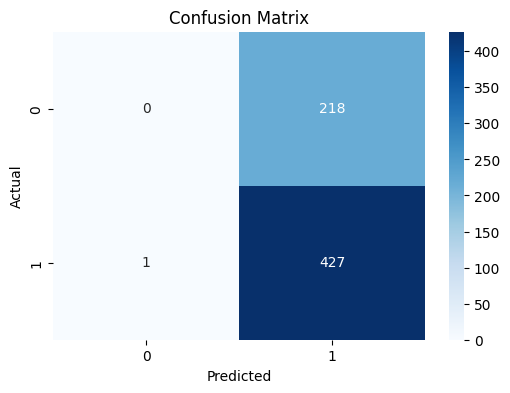

In [ ]:
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Save Model

In [ ]:
model.save("/content/crack_detection_sigmoid.h5")
print("Model saved")

Model saved!
